<a href="https://colab.research.google.com/github/latentfield/EV-Price-Prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.impute import KNNImputer, SimpleImputer


# 2. Exploratory Data Analysis (EDA)

In [21]:
data = pd.read_csv('train.csv')
data

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원)
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077,AWD,13642,0,No,2,159.66
1,TRAIN_0001,K사,Niro,Nearly New,56.000,FWD,10199,6,No,0,28.01
2,TRAIN_0002,A사,eT,Brand New,91.200,AWD,2361,7,No,0,66.27
3,TRAIN_0003,A사,RSeTGT,Nearly New,NaN,AWD,21683,3,No,0,99.16
4,TRAIN_0004,B사,i5,Pre-Owned,61.018,AWD,178205,1,No,0,62.02
...,...,...,...,...,...,...,...,...,...,...,...
7492,TRAIN_7492,H사,ION5,Brand New,NaN,AWD,3773,10,No,0,35.95
7493,TRAIN_7493,B사,i3,Pre-Owned,46.000,RWD,135411,2,No,0,23.40
7494,TRAIN_7494,P사,TayCT,Brand New,NaN,AWD,1363,2,No,0,120.00
7495,TRAIN_7495,B사,i3,Nearly New,56.000,RWD,39445,6,No,2,24.00


In [22]:
data.columns

Index(['ID', '제조사', '모델', '차량상태', '배터리용량', '구동방식', '주행거리(km)', '보증기간(년)',
       '사고이력', '연식(년)', '가격(백만원)'],
      dtype='str')

In [23]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
배터리용량,4786.0,69.397187,15.283635,46.0,56.359,68.125,78.227,99.80
주행거리(km),7497.0,44287.979458,55204.064386,3.0,5465.000,17331.000,61252.000,199827.00
보증기간(년),7497.0,4.960918,3.155342,0.0,2.000,5.000,8.000,10.00
연식(년),7497.0,0.222489,0.569232,0.0,0.000,0.000,0.000,2.00
가격(백만원),7497.0,62.331949,36.646759,9.0,34.390,56.000,80.050,161.09


# Missing value check


In [24]:
data.isna().sum()

ID             0
제조사            0
모델             0
차량상태           0
배터리용량       2711
구동방식           0
주행거리(km)       0
보증기간(년)        0
사고이력           0
연식(년)          0
가격(백만원)        0
dtype: int64

# Analysing the battery-capacity column to decide how to impute it


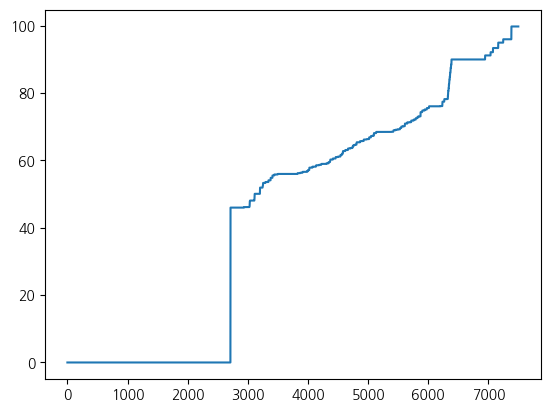

In [25]:
plt.plot(sorted(data['배터리용량'].fillna(0).tolist()))

In [26]:
data[data.describe().T.index].fillna(0).corr()

,배터리용량,주행거리(km),보증기간(년),연식(년),가격(백만원)
배터리용량,1.000000,0.238585,-0.262924,0.166370,0.043591
주행거리(km),0.238585,1.000000,-0.664071,-0.089586,-0.035488
보증기간(년),-0.262924,-0.664071,1.000000,0.035294,-0.349962
연식(년),0.166370,-0.089586,0.035294,1.000000,-0.058455
가격(백만원),0.043591,-0.035488,-0.349962,-0.058455,1.000000


* Battery capacity correlates only weakly with the other numerical columns.


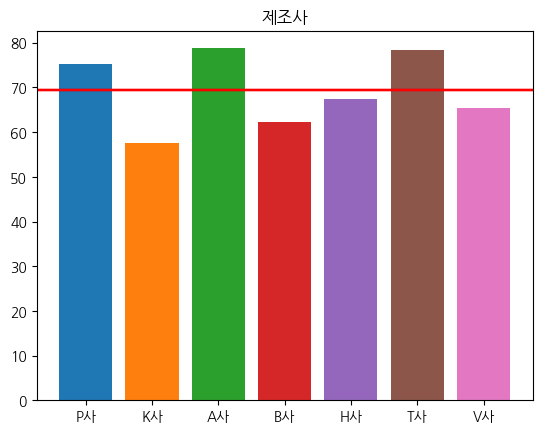

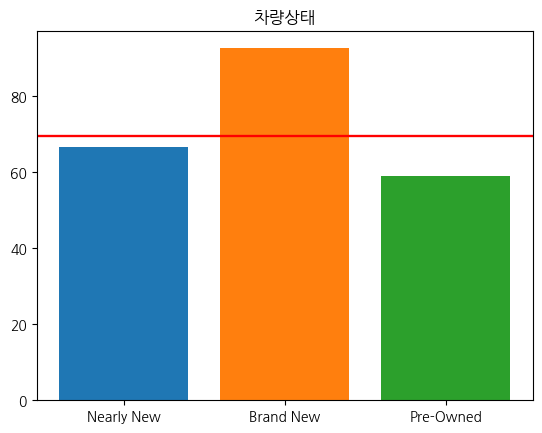

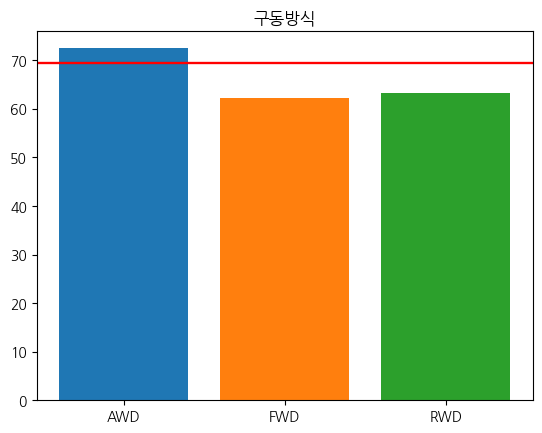

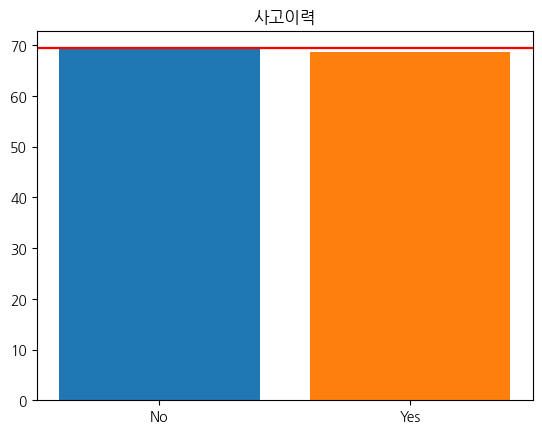

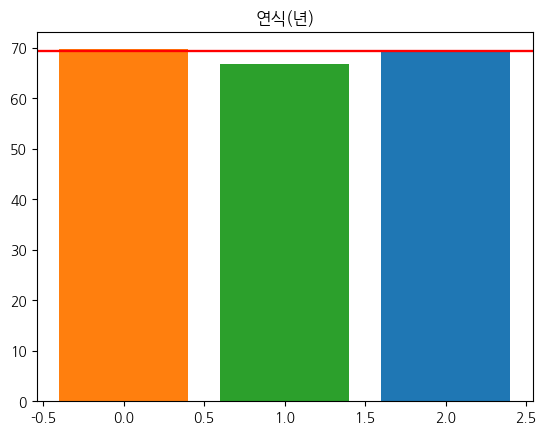

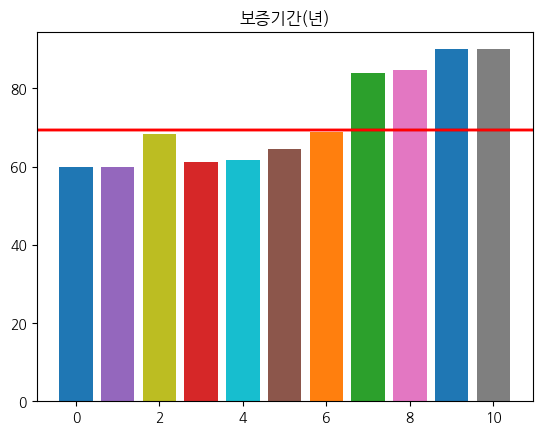

In [27]:
for idx, column_key in enumerate(['제조사', '차량상태', '구동방식', '사고이력', '연식(년)', '보증기간(년)']):
    for key in data[column_key].unique().tolist():
        plt.bar(key, data[data[column_key] == key]['배터리용량'].mean())
        plt.axhline(y=data['배터리용량'].mean(), color ='red')

    plt.axhline(y=data['배터리용량'].mean(), color='red')
    plt.title(column_key)
    plt.show()

Battery capacity:

1. Is noticeably larger when the warranty is 7 years or more.
2. Is larger for brand-new vehicles.


In [28]:
display(data[data['차량상태']=='Brand New'].describe().T)
display(data[data['차량상태']!='Brand New'].describe().T)

,count,mean,std,min,25%,50%,75%,max
배터리용량,1072.0,92.586567,3.357944,90.00,90.00,90.00,95.00,99.80
주행거리(km),3380.0,4935.953550,2897.745303,3.00,2372.75,4980.00,7440.75,9999.00
보증기간(년),3380.0,7.312130,2.407674,2.00,7.00,8.00,9.00,10.00
연식(년),3380.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
가격(백만원),3380.0,65.092287,34.653946,16.56,38.98,59.98,80.09,161.09


,count,mean,std,min,25%,50%,75%,max
배터리용량,3714.0,62.703860,9.884803,46.0,56.00,61.994,69.253,92.16
주행거리(km),4117.0,76595.447899,56810.649644,10004.0,30057.00,49850.000,123350.000,199827.00
보증기간(년),4117.0,3.030605,2.259745,0.0,1.00,3.000,5.000,8.00
연식(년),4117.0,0.405149,0.718391,0.0,0.00,0.000,1.000,2.00
가격(백만원),4117.0,60.065749,38.060008,9.0,27.83,51.250,79.300,160.52


In [29]:
print(data[data['차량상태']=='Brand New']['보증기간(년)'].mean())
print(data[data['차량상태']!='Brand New']['보증기간(년)'].mean())

7.312130177514793
3.03060480932718


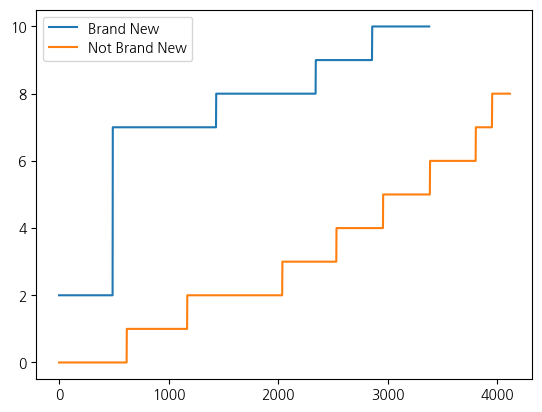

In [30]:
plt.plot(sorted(data[data['차량상태']=='Brand New']['보증기간(년)'].tolist()), label='Brand New')
plt.plot(sorted(data[data['차량상태']!='Brand New']['보증기간(년)'].tolist()), label='Not Brand New')
plt.legend(['Brand New', 'Not Brand New'])
plt.show()


Most brand-new vehicles carry a warranty of 7 years or more.

# Conclusion on imputing battery capacity
Split on warranty >= 7 years vs < 7 years and fill each group with its own mean.

*Implementation note: the cell below fills by manufacturer mean and then by the
global mean. The warranty split was explored here but is not what shipped.*


# Data Process

In [31]:
train_data = pd.read_csv('train.csv').drop(columns=['ID'])
submit_test_data = pd.read_csv('test.csv').drop(columns=['ID'])


In [34]:
numeric_cols = ['주행거리(km)', '보증기간(년)', '연식(년)']
knn_imputer = KNNImputer(n_neighbors=5)

train_data[numeric_cols] = knn_imputer.fit_transform(train_data[numeric_cols])
submit_test_data[numeric_cols] = knn_imputer.transform(submit_test_data[numeric_cols]) 

categorical_cols = ['제조사', '차량상태', '구동방식', '사고이력']
cat_imputer = SimpleImputer(strategy='most_frequent')

train_data[categorical_cols] = cat_imputer.fit_transform(train_data[categorical_cols])
submit_test_data[categorical_cols] = cat_imputer.transform(submit_test_data[categorical_cols])

train_data['배터리용량'] = train_data['배터리용량'].replace(-1, np.nan)
submit_test_data['배터리용량'] = submit_test_data['배터리용량'].replace(-1, np.nan)

battery_mean_by_maker = train_data.groupby('제조사')['배터리용량'].mean()

train_data['배터리용량'] = train_data['배터리용량'].fillna(train_data['제조사'].map(battery_mean_by_maker))
submit_test_data['배터리용량'] = submit_test_data['배터리용량'].fillna(submit_test_data['제조사'].map(battery_mean_by_maker))

train_data['배터리용량'] = train_data['배터리용량'].fillna(train_data['배터리용량'].mean())
submit_test_data['배터리용량'] = submit_test_data['배터리용량'].fillna(train_data['배터리용량'].mean())

In [35]:
encoder = LabelEncoder()
train_data['모델'] = encoder.fit_transform(train_data['모델'].astype(str))  # string labels -> integer codes
submit_test_data['모델'] = encoder.transform(submit_test_data['모델'].astype(str))

for col in categorical_cols:
    train_data[col] = encoder.fit_transform(train_data[col].astype(str))
    submit_test_data[col] = encoder.transform(submit_test_data[col].astype(str))
    train_data[col] = encoder.fit_transform(train_data[col])
    submit_test_data[col] = encoder.transform(submit_test_data[col])

In [36]:
X = train_data.drop(columns=['가격(백만원)'])
y = train_data['가격(백만원)']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
print(X_train.dtypes)

제조사           int64
모델            int64
차량상태          int64
배터리용량       float64
구동방식          int64
주행거리(km)    float64
보증기간(년)     float64
사고이력          int64
연식(년)       float64
dtype: object


# Model training


In [38]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
print(f"Random Forest RMSE: {rmse_rf}")

Random Forest RMSE: 1.6225470349114275


In [39]:
print("Actual price (y_valid) distribution:")
print(y_valid.describe())

print("\nPredicted price (y_pred) distribution:")
print(pd.Series(y_pred_rf).describe())

print(f"\nValidation RMSE: {rmse_rf:.4f} (million won)")

실제 가격 (y_valid) 분포:
count    1500.000000
mean       62.773573
std        37.079838
min         9.000000
25%        34.237500
50%        58.680000
75%        80.212500
max       161.090000
Name: 가격(백만원), dtype: float64

예측 가격 (y_pred) 분포:
count    1500.000000
mean       62.769245
std        36.963166
min        13.552400
25%        34.119675
50%        58.751600
75%        80.047025
max       160.740900
dtype: float64

Validation RMSE: 1.6225 (백만원 단위)


# Generating the submission file


In [40]:
final_pred = rf_model.predict(submit_test_data)

submission = pd.DataFrame({
    'ID': pd.read_csv('test.csv')['ID'],
    '가격(백만원)': final_pred
})

submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' successfully generated")

Submission file 'submission.csv' successfully generated
